In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.titlesize": 14,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.autolayout": True,
    }
)

In [4]:
DATA_PATH = ROOT_DIR / "data" / "processed" / "dataset_poc.parquet"
df = pd.read_parquet(DATA_PATH)

expected_features = [
    "material_balance",
    "tactical_tension",
    "hanging_pieces",
    "king_openness",
    "legal_moves_count",
    "mobility_ratio",
    "is_check",
    "absolute_pins",
    "has_queen_turn",
    "has_queen_opp",
    "player_elo",
    "ply",
    "delta_win",
    "is_blunder",
]
missing = [c for c in expected_features if c not in df.columns]
assert not missing, f"Kolom hilang: {missing}"

def get_phase(ply):
    if ply <= 20:
        return "Opening"
    elif ply <= 60:
        return "Middlegame"
    return "Endgame"

df["phase"] = df["ply"].apply(get_phase)

print(f"Total Baris Data: {len(df):,}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
df.head(3)

Total Baris Data: 10,000
Total Missing Values: 0


,material_balance,tactical_tension,hanging_pieces,king_openness,legal_moves_count,mobility_ratio,is_check,absolute_pins,has_queen_turn,has_queen_opp,player_elo,ply,delta_win,is_blunder,phase
0,-3,3,0,5,35,0.814,0,0,1,1,1335,28,0.0224,0,Middlegame
1,-4,3,0,8,36,0.783,0,0,1,1,1704,39,0.0000,0,Middlegame
2,0,2,0,5,25,0.758,0,0,1,1,1388,32,0.0124,0,Middlegame


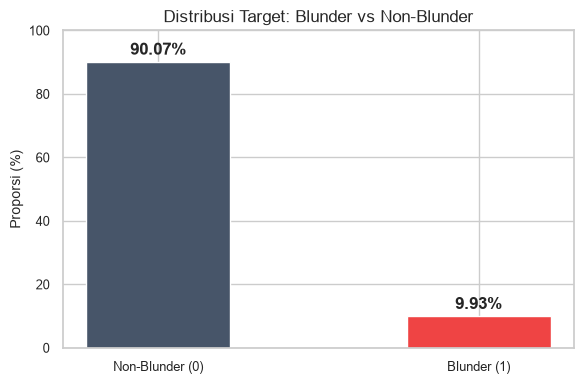

Rasio Imbalance = 9.07:1
Rekomendasi scale_pos_weight untuk XGBoost: 9.07


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df["is_blunder"].value_counts(normalize=True) * 100
colors = ["#475569", "#ef4444"]

bars = ax.bar(["Non-Blunder (0)", "Blunder (1)"], counts, color=colors, width=0.45)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 1.2,
        f"{yval:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_ylim(0, 100)
ax.set_ylabel("Proporsi (%)")
ax.set_title("Distribusi Target: Blunder vs Non-Blunder")
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"Rasio Imbalance = {imbalance_ratio:.2f}:1")
print(f"Rekomendasi scale_pos_weight untuk XGBoost: {imbalance_ratio:.2f}")

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_21164\1868195218.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=elo_stats, x="elo_bin", y="blunder_pct", palette="Blues_r", ax=ax)


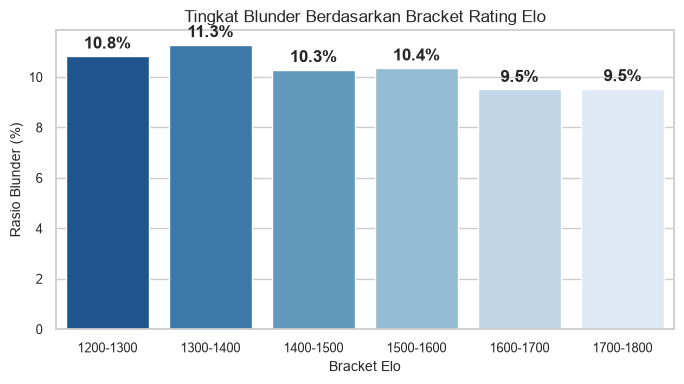

In [6]:
bins = list(range(1200, 1900, 100))
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]

df_target = df[(df["player_elo"] >= 1200) & (df["player_elo"] <= 1800)].copy()
df_target["elo_bin"] = pd.cut(
    df_target["player_elo"], bins=bins, labels=labels, include_lowest=True
)

elo_stats = (
    df_target.groupby("elo_bin", observed=True)["is_blunder"]
    .agg(blunder_rate="mean", total_moves="count")
    .reset_index()
)
elo_stats["blunder_pct"] = elo_stats["blunder_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=elo_stats, x="elo_bin", y="blunder_pct", palette="Blues_r", ax=ax)

for i, row in elo_stats.iterrows():
    ax.text(
        i,
        row["blunder_pct"] + 0.3,
        f"{row['blunder_pct']:.1f}%",
        ha="center",
        fontweight="bold",
    )

ax.set_title("Tingkat Blunder Berdasarkan Bracket Rating Elo")
ax.set_xlabel("Bracket Elo")
ax.set_ylabel("Rasio Blunder (%)")
plt.show()

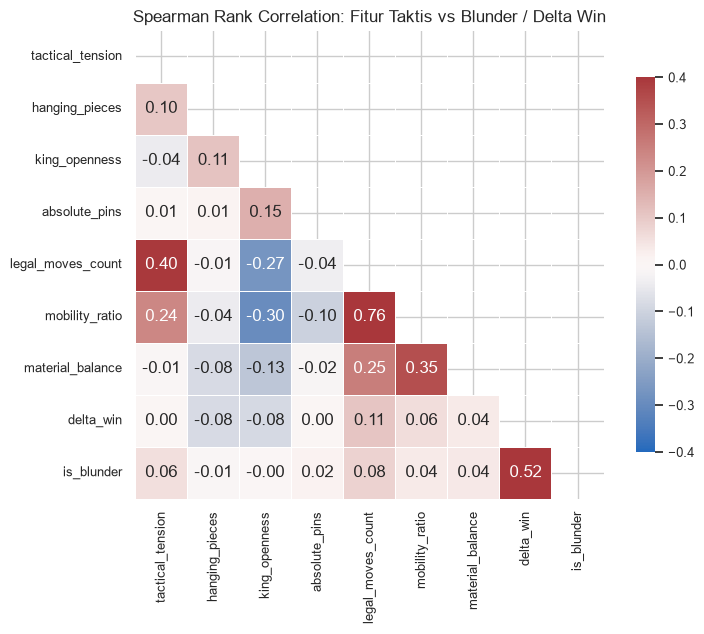

In [7]:
tactical_cols = [
    "tactical_tension",
    "hanging_pieces",
    "king_openness",
    "absolute_pins",
    "legal_moves_count",
    "mobility_ratio",
    "material_balance",
    "delta_win",
    "is_blunder",
]

corr = df[tactical_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-0.4,
    vmax=0.4,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Spearman Rank Correlation: Fitur Taktis vs Blunder / Delta Win")
plt.show()

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_21164\2251710524.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


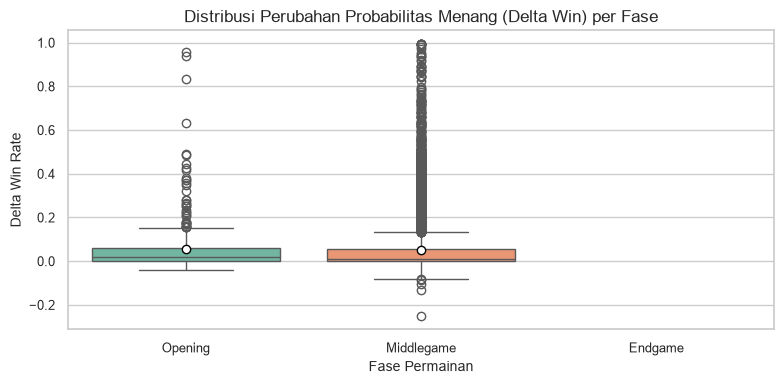

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

df["delta_win_vis"] = df["delta_win"].clip(lower=-1.0, upper=1.0)

sns.boxplot(
    data=df,
    x="phase",
    y="delta_win_vis",
    order=["Opening", "Middlegame", "Endgame"],
    palette="Set2",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"},
    ax=ax,
)

ax.set_xlabel("Fase Permainan")
ax.set_ylabel("Delta Win Rate")
ax.set_title("Distribusi Perubahan Probabilitas Menang (Delta Win) per Fase")
plt.show()